## Yasir Alghamdi 2230004157 | Image processing | Lab 4

### Thresholding

In [1]:
# Install libraries

import cv2                        # OpenCV: For real-time computer vision
from PIL import Image, ImageOps    # Pillow: For basic image manipulation
import skimage                    # scikit-image: For scientific analysis
from skimage import io, filters   # Common scikit-image submodules
from scipy import ndimage, misc   # SciPy (SkyPi): For multi-dimensional image processing
import matplotlib.pyplot as plt   # Matplotlib: For visualization and plotting
import matplotlib.image as mpimg  # Matplotlib's image loading utility
import numpy as np                # NumPy: The underlying array structure for all the above
import matplotlib.cm as cm

/var/folders/jw/rg2d2lxj1_x1q_wmm38pwx6w0000gn/T/ipykernel_41189/2056443182.py:7: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import ndimage, misc   # SciPy (SkyPi): For multi-dimensional image processing


In [4]:
# Lab Task 1: Apply thresholding with a fixed threshold on an image
import cv2
# Load the image in grayscale
img = cv2.imread('/Users/bosaleh_07/Desktop/Github/Image_Processing_ARTI-404_Labs/Lab 4/images/Parrot.png', cv2.IMREAD_GRAYSCALE)
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]
# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255,cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})',thresh)
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [1]:
# Lab Task 2: Histogram processing
# Step 1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

In [2]:
# Step 2: Load moon image
img = data.moon()

In [3]:
# Step 3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

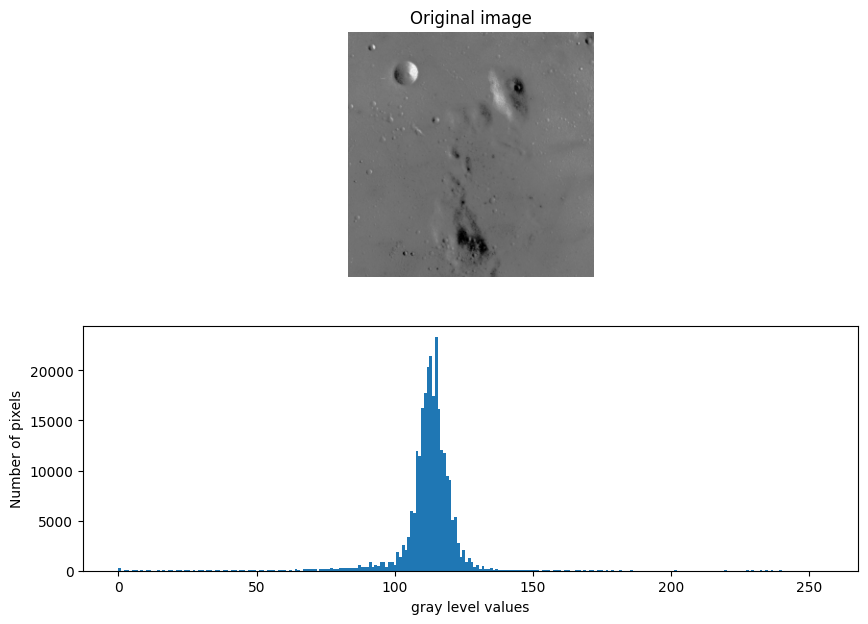

In [4]:
# Step 4: Display the image with its histogram of (step#2) and (step#3)
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

## Assessment

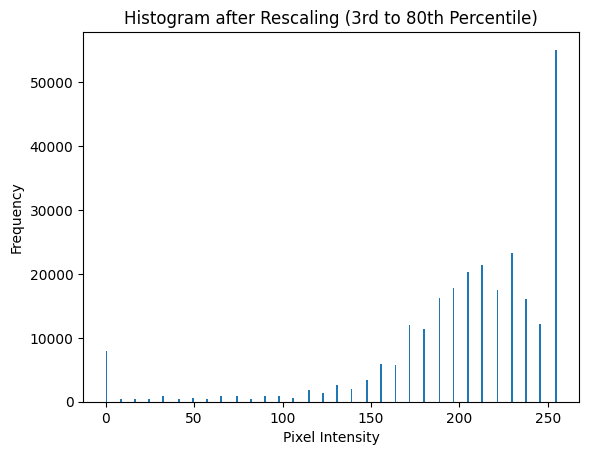

In [5]:
# Task 1: 
""" 
Using the same moon image Rescale intensity values to include all the intensities
that fall within the 3nd and 80th percentiles, and plot the histogram 
"""
# Compute the 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))

# Rescale intensities
rescaled = exposure.rescale_intensity(img, in_range=(p3, p80))

# Plot histogram
plt.figure()
plt.hist(rescaled.ravel(), bins=256)
plt.title("Histogram after Rescaling (3rd to 80th Percentile)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


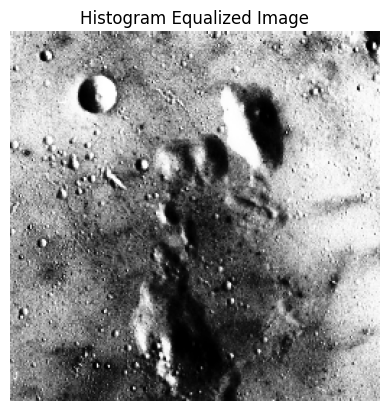

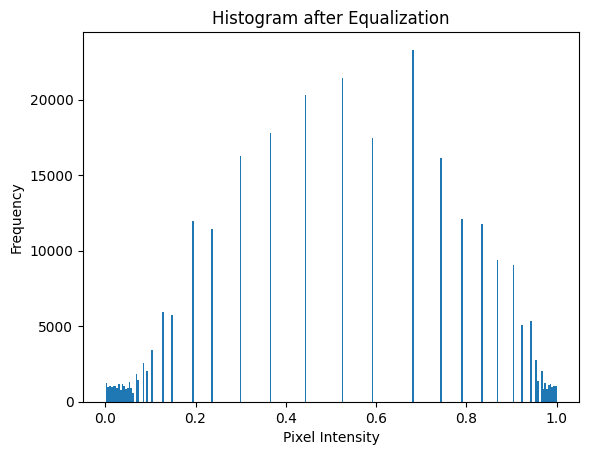

In [6]:
# Task 2:
"""
 Using the same ‘moon image’ and the exposure.equalize_hist function, display the
image and the histogram of the image after flattening the histogram.
"""
# Apply histogram equalization
equalized = exposure.equalize_hist(img)

# Display the equalized image
plt.figure()
plt.imshow(equalized, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()

# Plot histogram of equalized image
plt.figure()
plt.hist(equalized.ravel(), bins=256)
plt.title("Histogram after Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

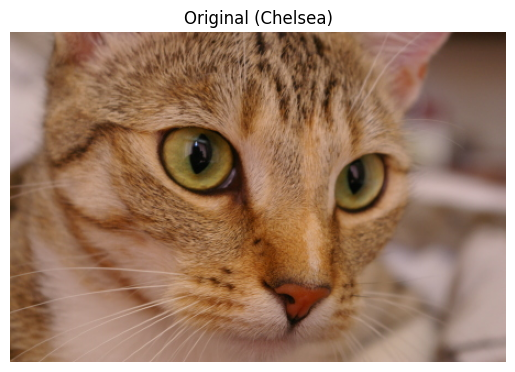

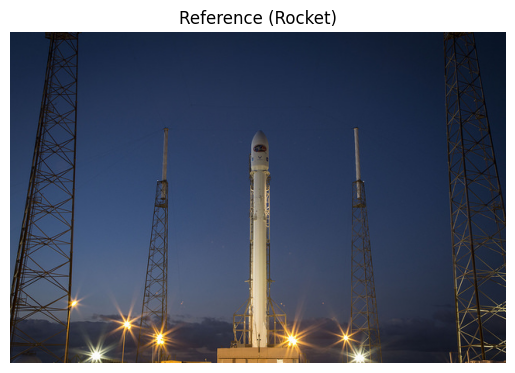

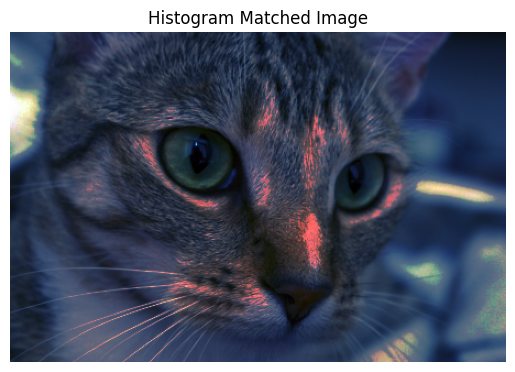

In [7]:
# Task 3:
"""
Use the rocket (as reference) and chelsea images (from skimage.data) and
implement histogram matching
"""
# Load images
reference = data.rocket()     # Reference image
source = data.chelsea()       # Image to transform

# Perform histogram matching
matched = exposure.match_histograms(source, reference, channel_axis=-1)

# Display results
plt.figure()
plt.imshow(source)
plt.title("Original (Chelsea)")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(reference)
plt.title("Reference (Rocket)")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(matched)
plt.title("Histogram Matched Image")
plt.axis('off')
plt.show()